In [1]:
from torch import nn
import torch
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt
import numpy as np

import os

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
data_dir = "c:/Users/tjagn/Desktop/chestxray/transformed/" # UWAGA - podajemy /transformed po wykonaniu transformations.py

In [3]:
# from data_utils import calculate_dataset_stats

# mean, std = calculate_dataset_stats(data_dir + "train/aug")
# print(f"TRAINING | Mean: {mean}, Std: {std}")

In [4]:
data_transform = transforms.Compose(
        [ 
        transforms.ToTensor(),
        transforms.Resize((256,256)),
        transforms.Normalize((0.4647, 0.4647, 0.4647), (0.2493, 0.2493, 0.2493))
        ]
    )

batch_size = 32

trainset = ImageFolder(data_dir + "train/aug", transform=data_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

valset = ImageFolder(data_dir + "val", transform=data_transform)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)

testset = ImageFolder(data_dir + "test", transform=data_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('NORMAL', 'BACTERIA', 'VIRUS')

In [5]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43200964..1.5736064].


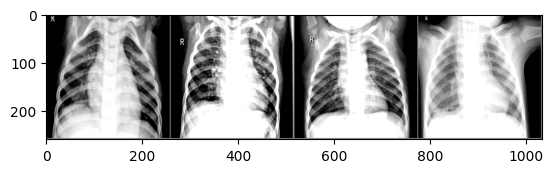

VIRUS NORMAL BACTERIA NORMAL


In [6]:
def imshow(img):
    img = img / 2 + 0.5    
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [7]:
total_images_train_normal = os.listdir(data_dir + "train/aug/NORMAL")
total_images_train_bacteria = os.listdir(data_dir + "train/aug/BACTERIA")
total_images_train_virus = os.listdir(data_dir + "train/aug/VIRUS")

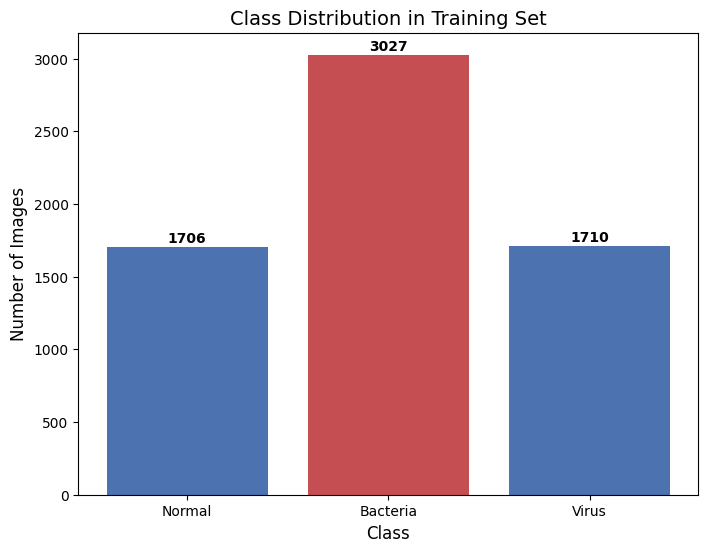

In [8]:
n_normal = len(total_images_train_normal)
n_bacteria = len(total_images_train_bacteria)
n_virus = len(total_images_train_virus)
classes = ['Normal', 'Bacteria', 'Virus']
counts = [n_normal, n_bacteria, n_virus]

plt.figure(figsize=(8, 6))
bars = plt.bar(classes, counts, color=['#4C72B0', '#C44E52'])

plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Training Set', fontsize=14)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontweight='bold')

plt.show()